# Machine Learning for Thermal Engineers
## Lesson 3: Overfitting

Author: Srikantan Natarajan

# 1. Problem Motivation

A machine learning model should not only fit the data it has already seen.

It should also perform well on **new data**.

Sometimes a model learns the training data too closely, including noise and random fluctuations. When that happens, it performs poorly on unseen data.

This problem is called **overfitting**.

# 2. Mathematical Intuition

Suppose measured data contains both:

- a real underlying trend
- random measurement noise

A simple model may miss the trend entirely (**underfitting**).

A very complex model may follow every fluctuation (**overfitting**).

The ideal model captures the true pattern without memorizing the noise.

In practice, this means we do **not** want a model that simply passes through every data point.

# 3. Engineering Analogy

For a thermal systems engineer, overfitting is similar to **over-tuned PID logic**.

If the controller gain is too high, the control system starts reacting to every small disturbance or bit of noise.

Instead of capturing the true system behavior, it becomes overly sensitive.

In machine learning, a model that is too flexible can behave the same way: it learns noise instead of learning the real relationship.

# 4. Python Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Create synthetic data
np.random.seed(0)
x = np.linspace(0, 10, 20)
y = 2 * x + 1 + np.random.normal(0, 3, 20)

x_reshaped = x.reshape(-1, 1)

# Simple linear model
linear_model = LinearRegression()
linear_model.fit(x_reshaped, y)
y_linear = linear_model.predict(x_reshaped)

# Highly flexible polynomial model
poly = PolynomialFeatures(degree=8)
x_poly = poly.fit_transform(x_reshaped)

poly_model = LinearRegression()
poly_model.fit(x_poly, y)
y_poly = poly_model.predict(x_poly)

In [ ]:
plt.scatter(x, y, label="Measured data")
plt.plot(x, y_linear, label="Linear model")
plt.plot(x, y_poly, label="Polynomial model (degree 8)")
plt.xlabel("Input variable")
plt.ylabel("Output variable")
plt.title("Good Fit vs Overfitting")
plt.legend()
plt.show()

# 5. Visualization

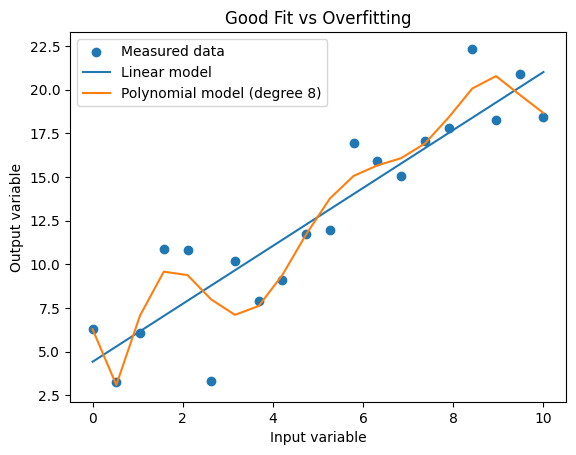

The linear model captures the overall trend in the data.

The polynomial model is much more flexible and bends aggressively to follow many individual points.

At first glance, the polynomial model may look impressive.

But it is actually learning noise in the dataset, not just the true pattern.

That is overfitting.

# 6. Key Takeaways

- A model should learn the true relationship, not memorize noise.
- A more complex model is not always a better model.
- Overfitting occurs when model flexibility becomes too high.
- In engineering terms, this is similar to a controller reacting too strongly to disturbances.

# 7. Try It Yourself

Change the polynomial degree and rerun the notebook:

- `degree = 2`
- `degree = 3`
- `degree = 12`

Questions to think about:

- At what degree does the model start looking unstable?
- Which curve best represents the true underlying trend?
- How does this compare with over-tuned compressor PID behavior?